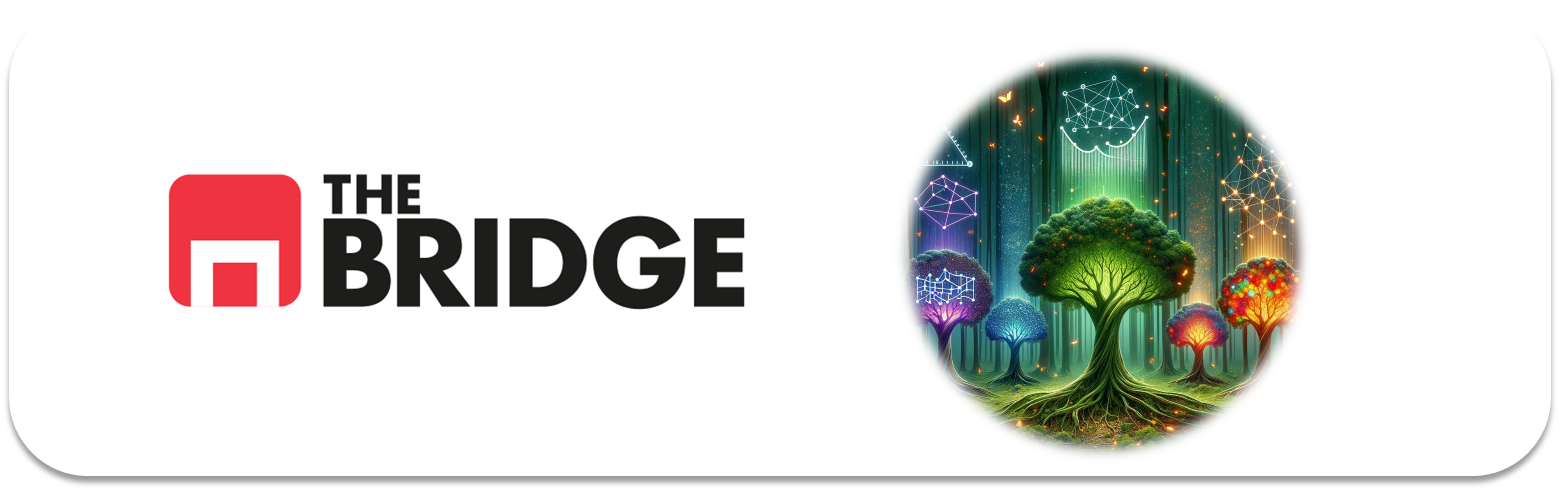

## PRACTICA OBLIGATORIA: **Arboles de Decisión y Ajuste de Hiperparámetros**

* La práctica obligatoria de esta unidad consiste en encontrar el mejor modelo para resolver un problema de predicción de si los destinatarios de una campaña de marketing adquirirán un producto concreto. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [ ]:
import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc
)
np.random.seed(42)

### Descripción

En el directorio data encontrarás un dataset que contiene datos relacionados con campañas de marketing directo de una institución bancaria portuguesa (es el dataset "Bank Marketing" de la UCI Machine Learning Repository). Los datos se recopilaron de campañas de marketing telefónico, donde el objetivo principal era predecir si el cliente se suscribiría a un depósito a plazo.

La práctica consiste en completar el proceso de creación de un modelo basado en árboles de decisión que permita predecir si un cliente (dadas unas características similares a las del dataset) "comprará" el depósito a plazo. Sigue los pasos necesarios de un proceso de ML para crear el modelo, optimizar sus hiperparámetros, comparar los resultados de esa optimización con una regresión logística (sin optimizar, con sus hiperparámetros por defecto) y finalmente evaluarlo contra test y hacer una pequeña valoración del resultado obtenido.

Tendrás que hacer la limpieza, split, minieda, selección, tratamiento, primeros entrenamientos, optimización, comparación y evaluación según tu mejor criterio. Eso sí, es obligatorio:
- Identificar el target y analizar su distribución
- Realizar una optimización de hiperparámetros, escogiendo un grid medianemante razonado
- Comparar con el modelo baseline
- Evaluar contra test

AYUDA: La dirección del banco nos proporciona estas notas (en inglés):

 
   **bank client data:**  
   1 - age (numeric)  
   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services")   
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)  
   4 - education (categorical: "unknown","secondary","primary","tertiary")  
   5 - default: has credit in default? (binary: "yes","no")  
   6 - balance: average yearly balance, in euros (numeric)   
   7 - housing: has housing loan? (binary: "yes","no")  
   8 - loan: has personal loan? (binary: "yes","no")   

   **related with the last contact of the current campaign:**  
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular")   
  10 - day: last contact day of the month (numeric)  
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")  
  12 - duration: last contact duration, in seconds (numeric)    

   **other attributes:**  
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)  
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)  
  15 - previous: number of contacts performed before this campaign and for this client (numeric)  
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

In [2]:
df = pd.read_csv("./data/bank-full.csv", sep = ";")

In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [5]:
df.isnull().sum().sum()

np.int64(0)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
target = "y"

In [8]:
# análisis del target
df.y.value_counts(normalize= True).round(2)

y
no     0.88
yes    0.12
Name: proportion, dtype: float64

In [9]:
# codificamos target como binaria: 0 = no, 1 = yes

In [10]:
df["y_bin"] = (df["y"] == "yes").astype(int)

In [11]:
df.y_bin.value_counts()

y_bin
0    39922
1     5289
Name: count, dtype: int64

In [12]:
# Train/Test split estratificado

In [13]:
target = "y_bin"

X = df.drop(columns=["y", "y_bin"])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"\nProporcion target en train: {y_train.mean():.3f}")
print(f"Proporcion target en test:  {y_test.mean():.3f}")

Train: (36168, 16)  |  Test: (9043, 16)

Proporcion target en train: 0.117
Proporcion target en test:  0.117


C:\Users\PC\AppData\Local\Temp\ipykernel_16600\3462967778.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_etiquetas, palette=["salmon", "steelblue"])


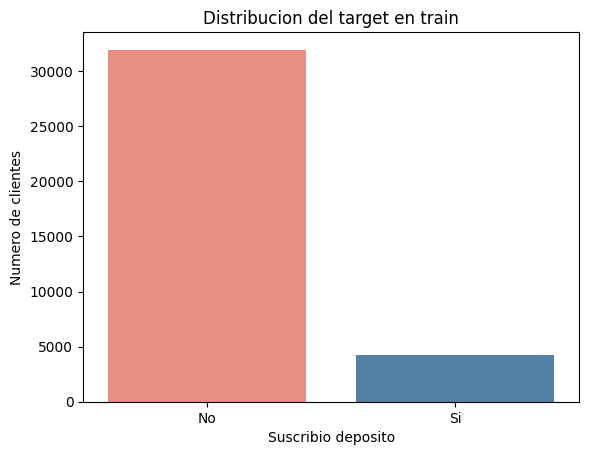

In [14]:
y_train_etiquetas = y_train.map({0: "No", 1: "Si"})

sns.countplot(x=y_train_etiquetas, palette=["salmon", "steelblue"])
plt.title("Distribucion del target en train")
plt.xlabel("Suscribio deposito")
plt.ylabel("Numero de clientes")
plt.show()

In [15]:
# Conjunto de trabajo para el EDA (solo train)
train_set = X_train.copy()
train_set[target] = y_train
train_set.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y_bin
24001,36,technician,divorced,secondary,no,861,no,no,telephone,29,aug,140,2,-1,0,unknown,0
43409,24,student,single,secondary,no,4126,no,no,cellular,5,apr,907,4,185,7,failure,1
20669,44,technician,single,secondary,no,244,yes,no,cellular,12,aug,1735,4,-1,0,unknown,1
18810,48,unemployed,married,secondary,no,0,no,no,telephone,31,jul,35,11,-1,0,unknown,0
23130,38,technician,married,secondary,no,257,no,no,cellular,26,aug,57,10,-1,0,unknown,0


In [16]:
# EDA sobre train

In [17]:
# Numéricas

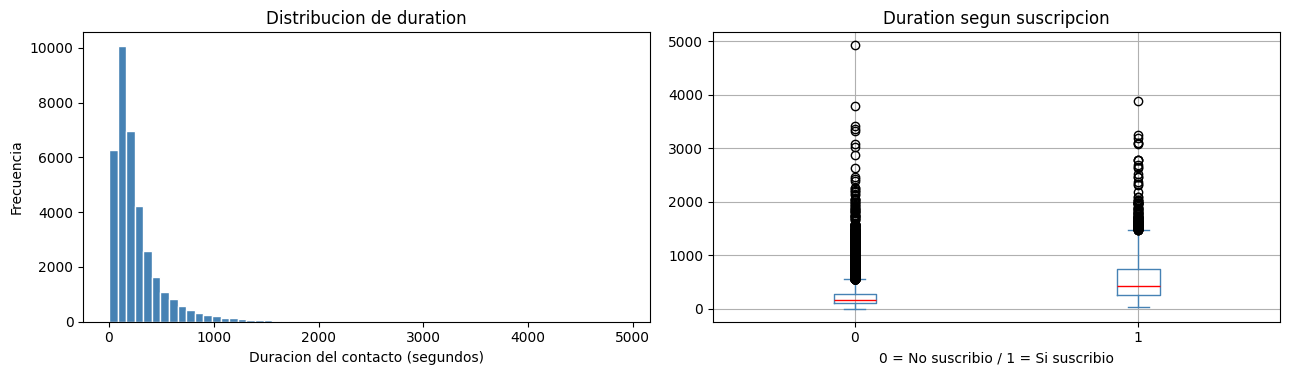

In [18]:
# duration: duracion del ultimo contacto
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(train_set["duration"], bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Distribucion de duration")
axes[0].set_xlabel("Duracion del contacto (segundos)")
axes[0].set_ylabel("Frecuencia")

train_set.boxplot(column="duration", by=target, ax=axes[1],
                  boxprops=dict(color="steelblue"), medianprops=dict(color="red"),
                  whiskerprops=dict(color="steelblue"), capprops=dict(color="steelblue"))
axes[1].set_title("Duration segun suscripcion")
axes[1].set_xlabel("0 = No suscribio / 1 = Si suscribio")
plt.suptitle("")
plt.tight_layout()
plt.show()

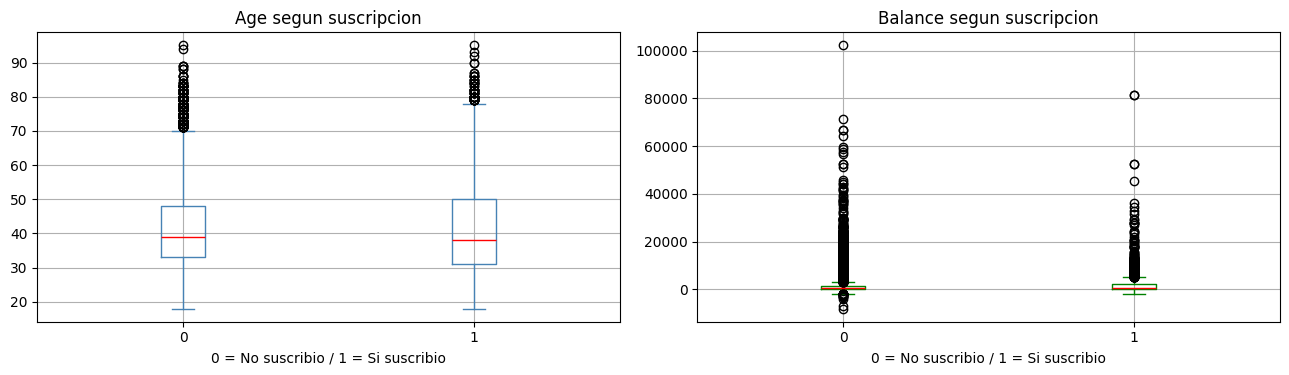

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

train_set.boxplot(column="age", by=target, ax=axes[0],
                  boxprops=dict(color="steelblue"), medianprops=dict(color="red"),
                  whiskerprops=dict(color="steelblue"), capprops=dict(color="steelblue"))
axes[0].set_title("Age segun suscripcion")
axes[0].set_xlabel("0 = No suscribio / 1 = Si suscribio")

train_set.boxplot(column="balance", by=target, ax=axes[1],
                  boxprops=dict(color="green"), medianprops=dict(color="red"),
                  whiskerprops=dict(color="green"), capprops=dict(color="green"))
axes[1].set_title("Balance segun suscripcion")
axes[1].set_xlabel("0 = No suscribio / 1 = Si suscribio")

plt.suptitle("")
plt.tight_layout()
plt.show()

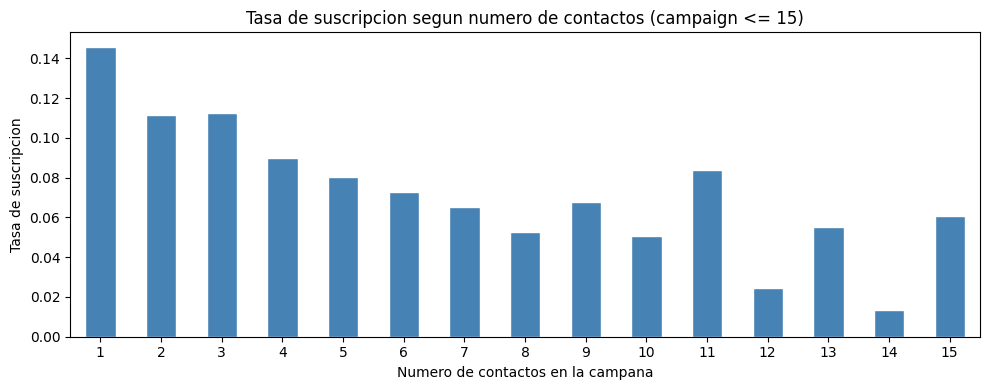

In [20]:
# Tasa de suscripcion segun numero de contactos en campana
surv_campaign = train_set.groupby("campaign")[target].mean()

plt.figure(figsize=(10, 4))
surv_campaign[surv_campaign.index <= 15].plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("Tasa de suscripcion segun numero de contactos (campaign <= 15)")
plt.xlabel("Numero de contactos en la campana")
plt.ylabel("Tasa de suscripcion")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
# Categóricas

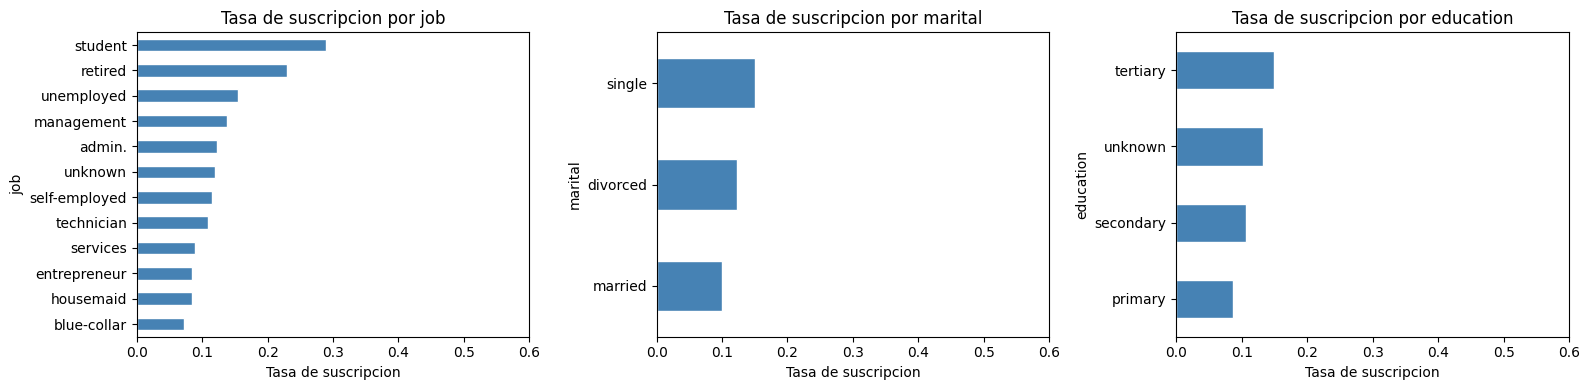

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ["job", "marital", "education"]):
    tasa = train_set.groupby(col)[target].mean().sort_values()
    tasa.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"Tasa de suscripcion por {col}")
    ax.set_xlabel("Tasa de suscripcion")
    ax.set_xlim(0, 0.6)

plt.tight_layout()
plt.show()

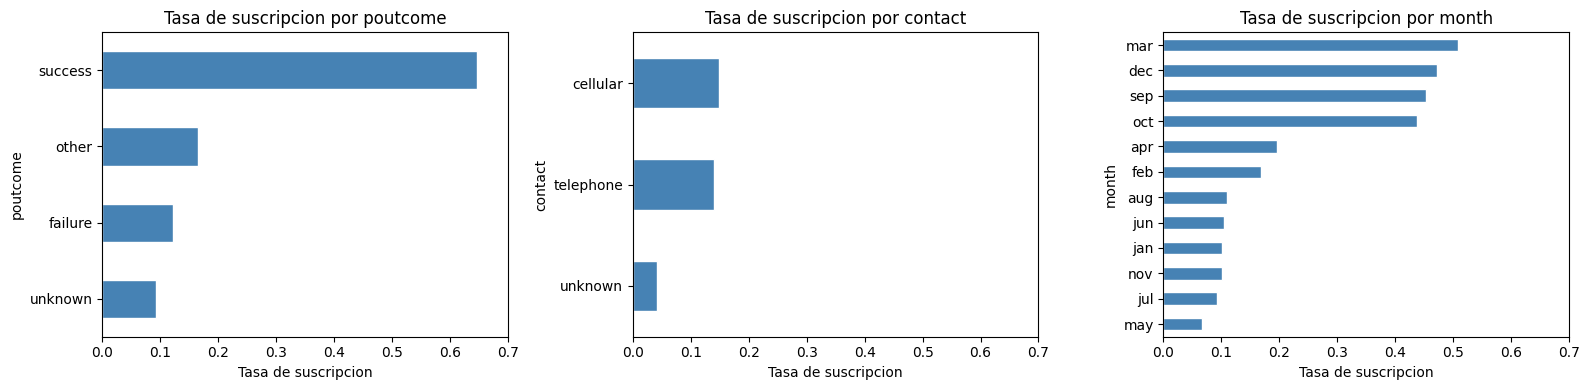

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ["poutcome", "contact", "month"]):
    tasa = train_set.groupby(col)[target].mean().sort_values()
    tasa.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"Tasa de suscripcion por {col}")
    ax.set_xlabel("Tasa de suscripcion")
    ax.set_xlim(0, 0.7)

plt.tight_layout()
plt.show()

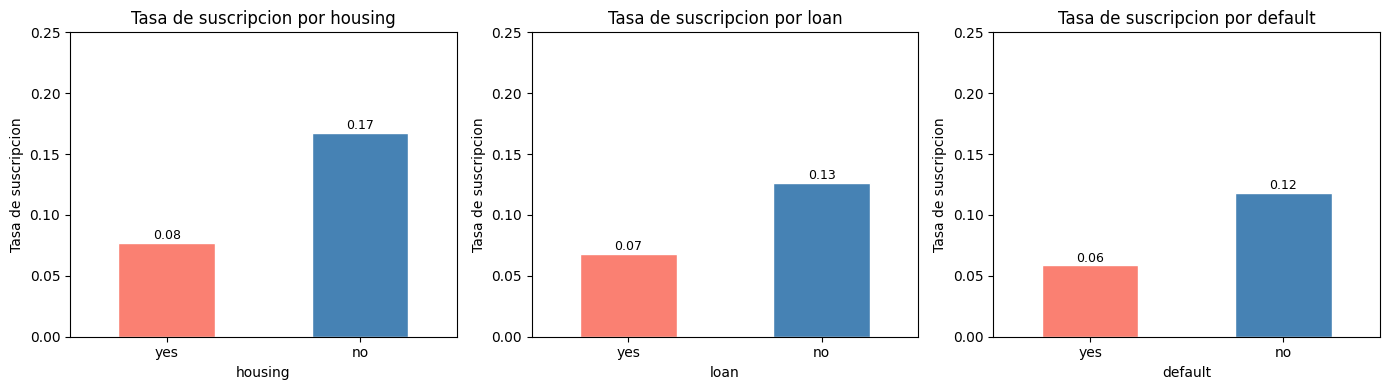

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ["housing", "loan", "default"]):
    tasa = train_set.groupby(col)[target].mean().sort_values()
    tasa.plot(kind="bar", ax=ax, color=["salmon", "steelblue"], edgecolor="white")
    ax.set_title(f"Tasa de suscripcion por {col}")
    ax.set_ylabel("Tasa de suscripcion")
    ax.set_ylim(0, 0.25)
    ax.tick_params(axis="x", rotation=0)
    for i, v in enumerate(tasa.values):
        ax.text(i, v + 0.003, f"{v:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [25]:
# Correlacion numéricas con target

Correlacion de Pearson con y_bin:
campaign   -0.072
day        -0.027
age         0.025
balance     0.055
previous    0.089
pdays       0.101
duration    0.397
Name: y_bin, dtype: float64


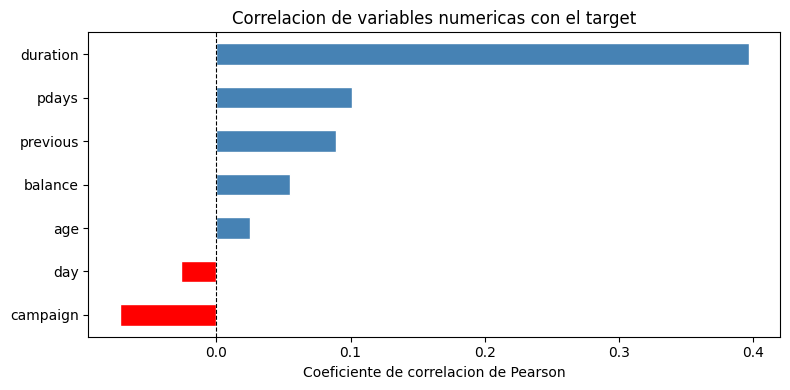

In [26]:
num_cols_plot = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
corr_target = train_set[num_cols_plot + [target]].corr()[target].drop(target).sort_values()

print("Correlacion de Pearson con y_bin:")
print(corr_target.round(3))

colors = ["red" if v < 0 else "steelblue" for v in corr_target]
corr_target.plot(kind="barh", color=colors, edgecolor="white", figsize=(8, 4))
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Correlacion de variables numericas con el target")
plt.xlabel("Coeficiente de correlacion de Pearson")
plt.tight_layout()
plt.show()

In [27]:
# Preprocesado - pipeline

In [28]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

print(f"Variables numericas ({len(num_cols)}): {num_cols}")
print(f"Variables categoricas ({len(cat_cols)}): {cat_cols}")

Variables numericas (7): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Variables categoricas (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [29]:
# Pipeline para variables numericas
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline para variables categoricas
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# ColumnTransformer que combina ambos pipelines
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

print("Pipeline de preprocesado definido correctamente.")

Pipeline de preprocesado definido correctamente.


In [30]:
# árbol de decisión sin optimizar

In [31]:
dt_default = Pipeline([
    ("preprocessing", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

dt_default.fit(X_train, y_train)

y_pred_dt_default = dt_default.predict(X_test)
y_proba_dt_default = dt_default.predict_proba(X_test)[:, 1]

# Evaluacion en train para detectar overfitting
y_pred_dt_train = dt_default.predict(X_train)
y_proba_dt_train = dt_default.predict_proba(X_train)[:, 1]

print("Arbol de Decision (parametros por defecto)")
print("-" * 45)
print(f"TRAIN  Balanced Accuracy: {balanced_accuracy_score(y_train, y_pred_dt_train):.3f}")
print(f"TRAIN  ROC-AUC:           {roc_auc_score(y_train, y_proba_dt_train):.3f}")
print()
print(f"TEST   Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_dt_default):.3f}")
print(f"TEST   ROC-AUC:           {roc_auc_score(y_test, y_proba_dt_default):.3f}")
print()
depth = dt_default.named_steps['model'].get_depth()
n_leaves = dt_default.named_steps['model'].get_n_leaves()
print(f"Profundidad del arbol: {depth}")
print(f"Numero de hojas:       {n_leaves}")

Arbol de Decision (parametros por defecto)
---------------------------------------------
TRAIN  Balanced Accuracy: 1.000
TRAIN  ROC-AUC:           1.000

TEST   Balanced Accuracy: 0.693
TEST   ROC-AUC:           0.693

Profundidad del arbol: 40
Numero de hojas:       3860


In [32]:
# regresión logística

In [33]:
log_model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_proba_log = log_model.predict_proba(X_test)[:, 1]

print("Regresion Logistica (baseline)")
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_log))
print("ROC-AUC:",           roc_auc_score(y_test, y_proba_log))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Regresion Logistica (baseline)
Balanced Accuracy: 0.8322941289965945
ROC-AUC: 0.9079218714674134

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.85      0.91      7985
           1       0.42      0.81      0.55      1058

    accuracy                           0.85      9043
   macro avg       0.70      0.83      0.73      9043
weighted avg       0.91      0.85      0.87      9043



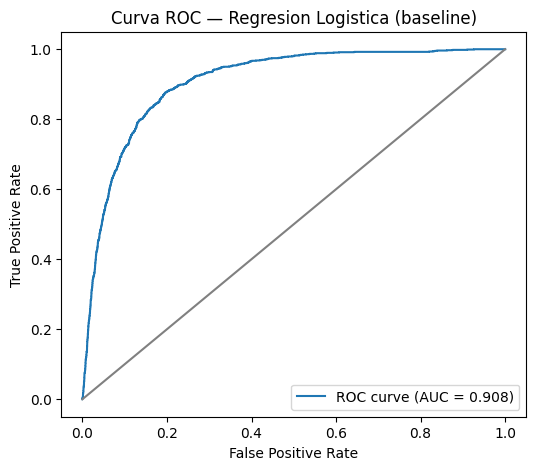

In [34]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)

plt.figure(figsize=(6, 5))
plt.plot(fpr_log, tpr_log, label=f"ROC curve (AUC = {roc_auc_score(y_test, y_proba_log):.3f})")
plt.plot([0, 1], [0, 1], color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC — Regresion Logistica (baseline)")
plt.legend()
plt.show()

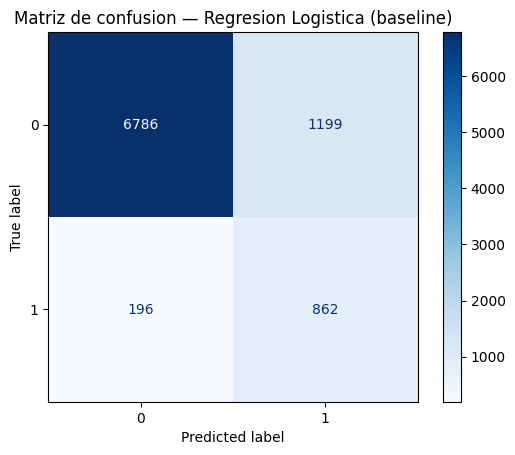

In [35]:
cm_log = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(cm_log)
disp.plot(cmap="Blues")
plt.title("Matriz de confusion — Regresion Logistica (baseline)")
plt.show()

In [36]:
# optimizacion de hiperparametros

In [37]:
# Validacion cruzada estratificada — mantiene la proporcion de clases en cada fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pipeline con preprocesado + arbol de decision
dt_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"    # compensa el desbalance 88/12
    ))
])

# Rejilla de hiperparametros
param_grid = {
    "model__max_depth":[4, 6, 8, 10], # profundidad maxima del arbol
    "model__min_samples_split":[10, 20, 50], # min. muestras para dividir un nodo
    "model__min_samples_leaf":[5, 10, 20], # min. muestras en hoja terminal
    "model__criterion":["gini", "entropy"]   # criterio de impureza
}

print("Configuracion GridSearchCV lista.")
total_combos = 4 * 3 * 3 * 2
print(f"Combinaciones totales: {total_combos} x 5 folds = {total_combos * 5} ajustes")

Configuracion GridSearchCV lista.
Combinaciones totales: 72 x 5 folds = 360 ajustes


In [38]:
grid = GridSearchCV(
    estimator=dt_pipe,
    param_grid=param_grid,
    scoring={
        "bal_acc": "balanced_accuracy",  # metrica principal
        "roc_auc": "roc_auc"  # metrica secundaria
    },
    refit="bal_acc", # el mejor modelo se elige por balanced accuracy
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__criterion': ['gini', 'entropy'], 'model__max_depth': [4, 6, ...], 'model__min_samples_leaf': [5, 10, ...], 'model__min_samples_split': [10, 20, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'bal_acc': 'balanced_accuracy', 'roc_auc': 'roc_auc'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'bal_acc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose 

In [39]:
print("Mejores hiperparametros encontrados:")
print(grid.best_params_)

print(f"\nMejor Balanced Accuracy en CV: {grid.best_score_:.4f}")

Mejores hiperparametros encontrados:
{'model__criterion': 'gini', 'model__max_depth': 10, 'model__min_samples_leaf': 10, 'model__min_samples_split': 50}

Mejor Balanced Accuracy en CV: 0.8379


In [40]:
# Evaluación modelo optimizado

In [41]:
best_model = grid.best_estimator_

# Predicciones en test
y_pred_opt  = best_model.predict(X_test)
y_proba_opt = best_model.predict_proba(X_test)[:, 1]

# Predicciones en train (chequeo de overfitting)
y_pred_train_opt  = best_model.predict(X_train)
y_proba_train_opt = best_model.predict_proba(X_train)[:, 1]

print("Arbol de Decision optimizado")
print("-" * 45)
print(f"TRAIN  Balanced Accuracy: {balanced_accuracy_score(y_train, y_pred_train_opt):.3f}")
print(f"TRAIN  ROC-AUC:           {roc_auc_score(y_train, y_proba_train_opt):.3f}")
print()
print(f"TEST   Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_opt):.3f}")
print(f"TEST   ROC-AUC:           {roc_auc_score(y_test, y_proba_opt):.3f}")

Arbol de Decision optimizado
---------------------------------------------
TRAIN  Balanced Accuracy: 0.871
TRAIN  ROC-AUC:           0.934

TEST   Balanced Accuracy: 0.842
TEST   ROC-AUC:           0.899


In [42]:
print("Classification Report — Arbol de Decision optimizado (Test):\n")
print(classification_report(y_test, y_pred_opt))

Classification Report — Arbol de Decision optimizado (Test):

              precision    recall  f1-score   support

           0       0.98      0.82      0.89      7985
           1       0.39      0.86      0.54      1058

    accuracy                           0.83      9043
   macro avg       0.68      0.84      0.71      9043
weighted avg       0.91      0.83      0.85      9043



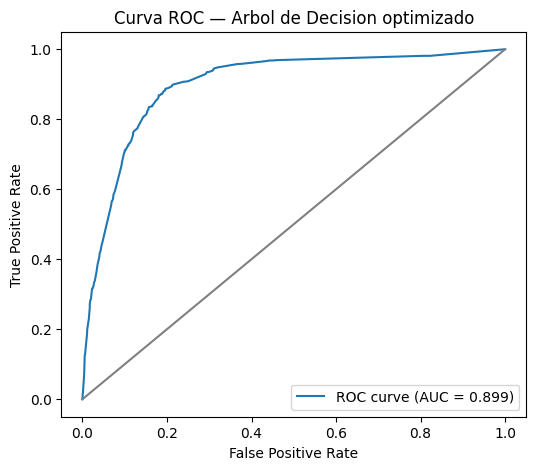

In [43]:
fpr_opt, tpr_opt, _ = roc_curve(y_test, y_proba_opt)
roc_auc_opt = auc(fpr_opt, tpr_opt)

plt.figure(figsize=(6, 5))
plt.plot(fpr_opt, tpr_opt, label=f"ROC curve (AUC = {roc_auc_opt:.3f})")
plt.plot([0, 1], [0, 1], color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC — Arbol de Decision optimizado")
plt.legend()
plt.show()

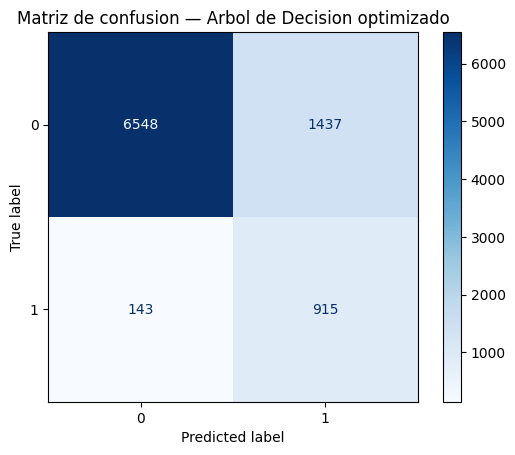

In [44]:
cm_opt = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(cm_opt)
disp.plot(cmap="Blues")
plt.title("Matriz de confusion — Arbol de Decision optimizado")
plt.show()

In [45]:
# Comparación: árbol de decisión optimizado vs regresión logística (baseline)

In [46]:
results = pd.DataFrame({
    "Modelo": ["Decision Tree (sin optimizar)", "Logistic Regression (baseline)", "Decision Tree (optimizado)"],
    "Balanced Accuracy": [
        balanced_accuracy_score(y_test, y_pred_dt_default),
        balanced_accuracy_score(y_test, y_pred_log),
        balanced_accuracy_score(y_test, y_pred_opt)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_dt_default),
        roc_auc_score(y_test, y_proba_log),
        roc_auc_score(y_test, y_proba_opt)
    ]
})

results = results.set_index("Modelo")
results = results.round(3)
results

,Balanced Accuracy,ROC-AUC
Modelo,,
Decision Tree (sin optimizar),0.693,0.693
Logistic Regression (baseline),0.832,0.908
Decision Tree (optimizado),0.842,0.899


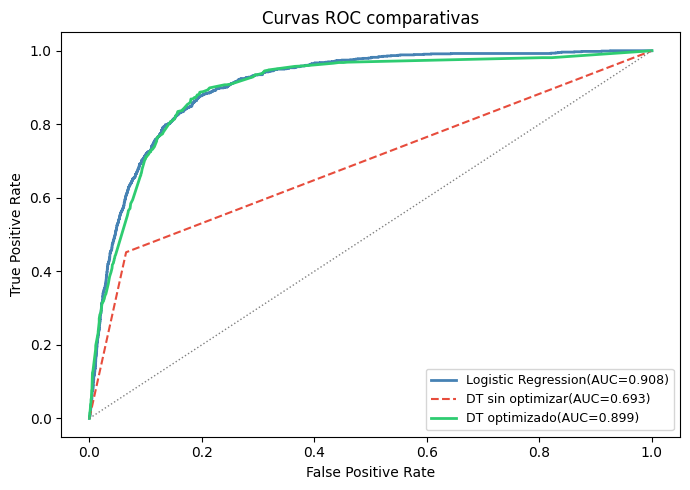

In [47]:
# Curvas ROC superpuestas para comparacion visual
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_default, tpr_default, _ = roc_curve(y_test, y_proba_dt_default)
fpr_opt, tpr_opt, _ = roc_curve(y_test, y_proba_opt)

plt.figure(figsize=(7, 5))
plt.plot(fpr_log, tpr_log,label=f"Logistic Regression(AUC={roc_auc_score(y_test, y_proba_log):.3f})",     color="steelblue",  lw=2)
plt.plot(fpr_default,tpr_default, label=f"DT sin optimizar(AUC={roc_auc_score(y_test, y_proba_dt_default):.3f})", color="#E74C3C",  lw=1.5, linestyle="--")
plt.plot(fpr_opt, tpr_opt,label=f"DT optimizado(AUC={roc_auc_score(y_test, y_proba_opt):.3f})",     color="#2ECC71",   lw=2)
plt.plot([0, 1], [0, 1], linestyle=":", color="gray", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC comparativas")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [48]:
# importancia de variables

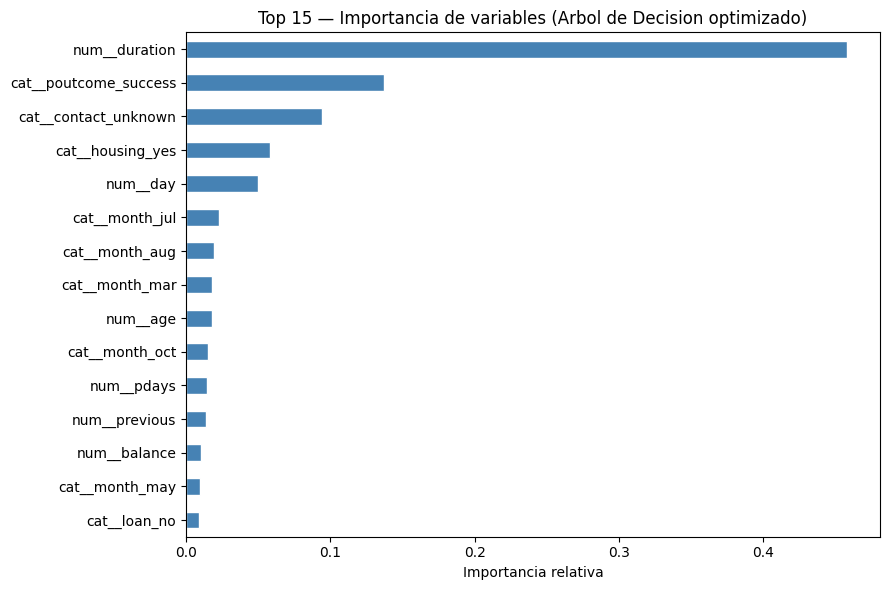

In [49]:
dt_step = best_model.named_steps["model"]
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

importances = pd.Series(
    dt_step.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

# Top 15
importances.head(15).plot(kind="barh", figsize=(9, 6), color="steelblue", edgecolor="white")
plt.title("Top 15 — Importancia de variables (Arbol de Decision optimizado)")
plt.xlabel("Importancia relativa")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [50]:
print("Top 15 variables mas importantes:")
print(importances.head(15).round(4).to_string())

Top 15 variables mas importantes:
num__duration            0.4578
cat__poutcome_success    0.1370
cat__contact_unknown     0.0939
cat__housing_yes         0.0578
num__day                 0.0495
cat__month_jul           0.0230
cat__month_aug           0.0191
cat__month_mar           0.0178
num__age                 0.0178
cat__month_oct           0.0152
num__pdays               0.0142
num__previous            0.0140
num__balance             0.0103
cat__month_may           0.0100
cat__loan_no             0.0088


In [51]:
# visualizaión árbol de decisión optimizado

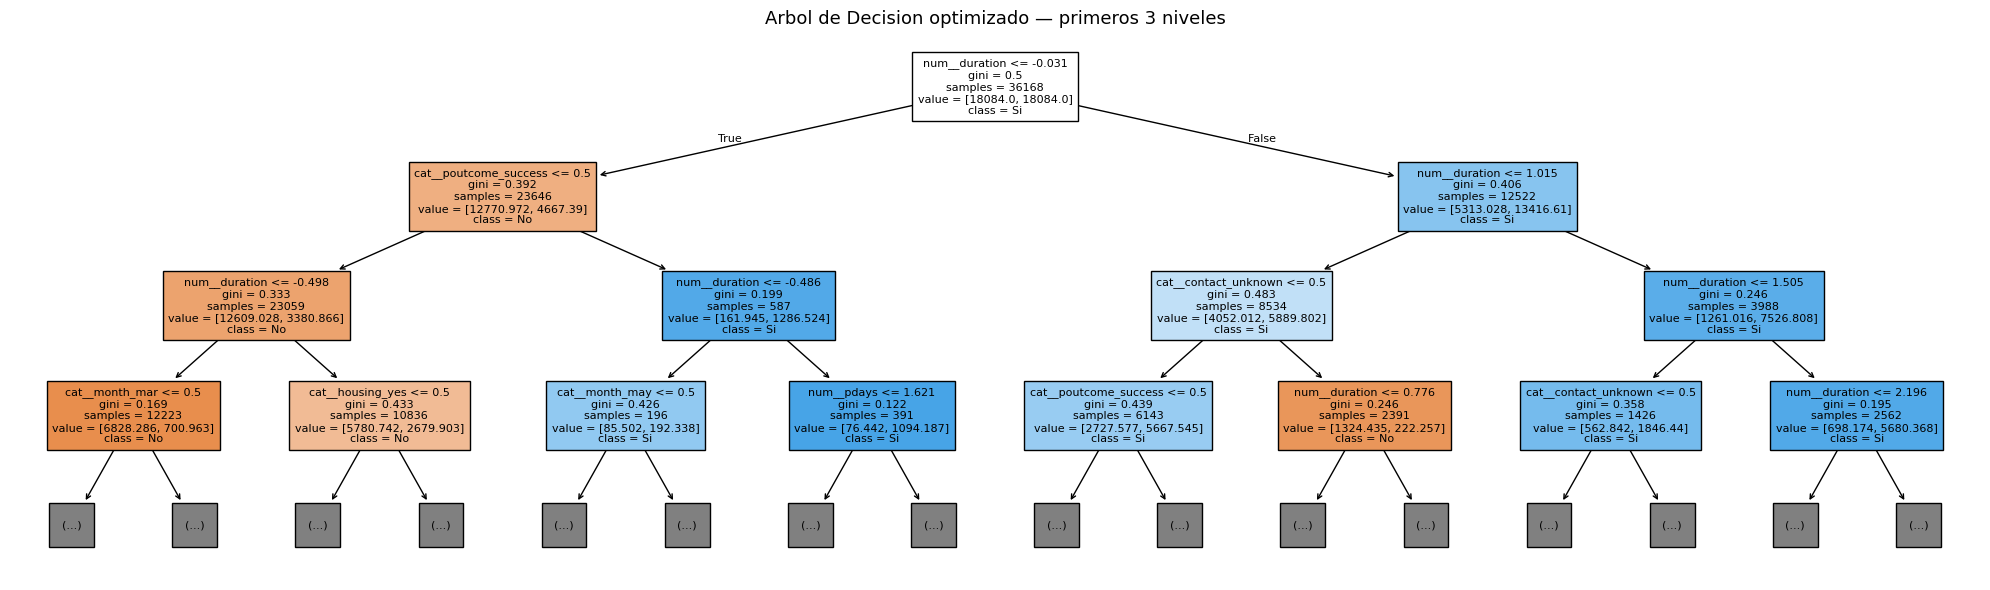

In [52]:
# Visualizacion de los primeros 3 niveles del arbol
fig, ax = plt.subplots(figsize=(20, 6))

plot_tree(
    dt_step,
    feature_names=feature_names,
    class_names=["No", "Si"],
    filled=True,
    max_depth=3,
    fontsize=8,
    ax=ax
)

plt.title("Arbol de Decision optimizado — primeros 3 niveles", fontsize=13)
plt.tight_layout()
plt.show()

In [53]:
# Representacion textual de los primeros 3 niveles
print("Primeras reglas del arbol (profundidad <= 3):")
print(export_text(dt_step, feature_names=list(feature_names), max_depth=3))   

Primeras reglas del arbol (profundidad <= 3):
|--- num__duration <= -0.03
|   |--- cat__poutcome_success <= 0.50
|   |   |--- num__duration <= -0.50
|   |   |   |--- cat__month_mar <= 0.50
|   |   |   |   |--- truncated branch of depth 7
|   |   |   |--- cat__month_mar >  0.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- num__duration >  -0.50
|   |   |   |--- cat__housing_yes <= 0.50
|   |   |   |   |--- truncated branch of depth 7
|   |   |   |--- cat__housing_yes >  0.50
|   |   |   |   |--- truncated branch of depth 7
|   |--- cat__poutcome_success >  0.50
|   |   |--- num__duration <= -0.49
|   |   |   |--- cat__month_may <= 0.50
|   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- cat__month_may >  0.50
|   |   |   |   |--- class: 0
|   |   |--- num__duration >  -0.49
|   |   |   |--- num__pdays <= 1.62
|   |   |   |   |--- truncated branch of depth 7
|   |   |   |--- num__pdays >  1.62
|   |   |   |   |--- truncated branch of depth 2
|--- num__durat